In [1]:
import pandas as pd

In [3]:
pip install bio

  Using cached gprofiler_official-1.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.4 MB/s  0:00:00 eta 0:00:01
Using cached gprofiler_official-1.0.0-py3-none-any.whl (9.3 kB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using c

In [2]:
from Bio import SeqIO

In [6]:
matrix_data = []

for record in SeqIO.parse("uniprotkb_tyrosine_AND_reviewed_true_2026_07_20.fasta", "fasta"):
    row = {
        "id_seq" : record.id,
        "description" : record.description,
        "sequence" : str(record.seq)
    }

    matrix_data.append(row)

df_data = pd.DataFrame(matrix_data)
df_data

,id_seq,description,sequence
0,sp|A0A061I403|FICD_CRIGR,sp|A0A061I403|FICD_CRIGR Protein adenylyltrans...,MPMASVIAVAEPKWISVWGRFLWLTLLSMALGSLLALLLPLGAVEE...
1,sp|A0A095C6S0|OXDA2_CRYD2,sp|A0A095C6S0|OXDA2_CRYD2 D-amino-acid oxidase...,MSFDAVVIGSGVIGLSIARELDNRGLKVAMVARDLAEDSLSVGFAS...
2,sp|A0A096MJN4|SEPT4_RAT,sp|A0A096MJN4|SEPT4_RAT Septin-4 OS=Rattus nor...,MIKHFLEDNSDDAELSKFVKDFPGSEPCHPTESKTRVARPQILEPR...
3,sp|A0A0B0QJR1|HEPT_APHF2,sp|A0A0B0QJR1|HEPT_APHF2 tRNA nuclease HepT OS...,MTNIEPVIIETRLELIGRYLDHLKKFENISLDDYLSSFEQQLITER...
4,sp|A0A0C1EH92|STMC_ASPUT,sp|A0A0C1EH92|STMC_ASPUT UDP-glycosyltransfera...,MTILSAERAPSRKILAVVTVGRYTCAAPILEICRILHTRGHTIEFA...
...,...,...,...
11802,sp|Q5EBF2|TTC36_XENTR,sp|Q5EBF2|TTC36_XENTR Tetratricopeptide repeat...,MCTPNDLAVLHAIFNPNVPFGNFDEQNVGDTEANADLDGRFSSAIL...
11803,sp|Q5RDW3|SAM12_PONAB,sp|Q5RDW3|SAM12_PONAB Sterile alpha motif doma...,MAVEALHCGLNPRGIDHPAHAEGIKLQIEGEGVESQSIKNKNFQKV...
11804,sp|Q60280|Y3520_METJA,sp|Q60280|Y3520_METJA Uncharacterized protein ...,MGKCRHNGEVSIFGVRPASFPYFPFNLMDRIGGFVILDELWLRRWC...
11805,sp|Q9D7E4|CS025_MOUSE,sp|Q9D7E4|CS025_MOUSE UPF0449 protein C19orf25...,MNSKAKKRVVLPTRPAPPTVEQILEDVRGAPAQDPVFTALAPEDPP...


In [9]:
length_data = []

for index in df_data.index:
    sequence = df_data["sequence"][index]
    length_data.append(len(sequence))
df_data["length_2"] = length_data

In [10]:
df_data["length"] = df_data["sequence"].str.len()
df_data[["length_2", "length"]].describe()

,length_2,length
count,11807.000000,11807.000000
mean,592.142119,592.142119
std,709.275540,709.275540
min,2.000000,2.000000
25%,302.000000,302.000000
50%,438.000000,438.000000
75%,721.500000,721.500000
max,35213.000000,35213.000000


In [12]:
df_data_filter = df_data[df_data["length"].between(70,1024)]
df_data_filter.shape

(10344, 5)

In [11]:
df_data[df_data["length"]>5000]

,id_seq,description,sequence,length,length_2
63,sp|A2ASS6|TITIN_MOUSE,sp|A2ASS6|TITIN_MOUSE Titin OS=Mus musculus OX...,MTTQAPMFTQPLQSVVVLEGSTATFEAHVSGSPVPEVSWFRDGQVI...,35213,35213
4645,sp|Q8WZ42|TITIN_HUMAN,sp|Q8WZ42|TITIN_HUMAN Titin OS=Homo sapiens OX...,MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...,34350,34350
5396,sp|Q9QYX7|PCLO_MOUSE,sp|Q9QYX7|PCLO_MOUSE Protein piccolo OS=Mus mu...,MGNEASLEGEGLPEGLAAAAGGAGGSGSALHPGIPAGMEADLSQLS...,5068,5068
5797,sp|A0A348AXX4|KK1B_CURCL,sp|A0A348AXX4|KK1B_CURCL Nonribosomal peptide ...,MASDINTHPEGATKFWQQHFDGLNASVFPALSSHLTVPRPNAQTAH...,13041,13041
6077,sp|B8NY88|AGIA_ASPFN,sp|B8NY88|AGIA_ASPFN Nonribosomal peptide synt...,MGSIGNVQSPLPRCVQSMHAPSVMQEEMIVSTIADPSHKSYFETYH...,7763,7763
6204,sp|O30409|TYCC_BREPA,sp|O30409|TYCC_BREPA Tyrocidine synthase 3 OS=...,MKKQENIAKIYPLTPLQEGMLFHAVTDTGSSAYCLQMSATIEGDFH...,6486,6486
6841,sp|Q09165|DIG1_CAEEL,sp|Q09165|DIG1_CAEEL Mesocentin OS=Caenorhabdi...,MGGRNWLFRSAVLVSTLLTCISIAQELLPSIEVESLAQDLQIQEWM...,13084,13084
7444,sp|Q70LM5|LGRC_BREPA,sp|Q70LM5|LGRC_BREPA Linear gramicidin synthas...,MNSMGDLTDLYTLTPLQEGMLFHSLYSEGSAYMIQTTAILTGELDI...,7756,7756
10685,sp|Q9R9J0|MYCB_BACIU,sp|Q9R9J0|MYCB_BACIU Mycosubtilin synthase sub...,MSVFKNQVTYWANLFDEEDSLSVIPYFKTAENASLTRVGYQEKSIY...,5369,5369


In [13]:
import seaborn as sns

<Axes: xlabel='length'>

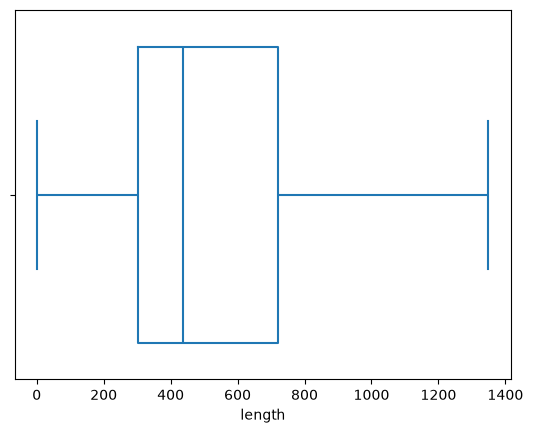

In [16]:
sns.boxplot(data=df_data, x="length", fill=False, showfliers=False)

In [21]:
IQR = df_data["length"].describe()["75%"]-df_data["length"].describe()["25%"]
lower_limit = (df_data["length"].describe()["25%"] - (1.5 * IQR))
upper_limit = (df_data["length"].describe()["75%"] + (1.5 * IQR))

In [22]:
lower_limit, upper_limit

(np.float64(-327.25), np.float64(1350.75))

In [25]:
df_data["is_not_outlier"] = df_data["length"].between(lower_limit, upper_limit)
df_data["is_not_outlier"].value_counts()

is_not_outlier
True     11081
False      726
Name: count, dtype: int64

In [26]:
df_data_filter = df_data[df_data["is_not_outlier"]]
df_data_filter.shape

(11081, 7)

<Axes: xlabel='length'>

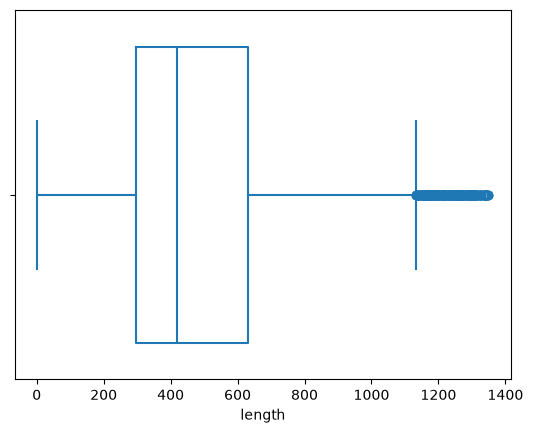

In [28]:
sns.boxplot(data=df_data_filter, x="length", fill=False)

In [29]:
IQR = df_data_filter["length"].describe()["75%"]-df_data_filter["length"].describe()["25%"]
lower_limit = (df_data_filter["length"].describe()["25%"] - (1.5 * IQR))
upper_limit = (df_data_filter["length"].describe()["75%"] + (1.5 * IQR))
lower_limit, upper_limit

(np.float64(-206.5), np.float64(1133.5))

In [30]:
df_data_filter["is_not_outlier_2"] = df_data_filter["length"].between(lower_limit, upper_limit)
df_data_filter["is_not_outlier_2"].value_counts()

is_not_outlier_2
True     10778
False      303
Name: count, dtype: int64

In [32]:
df_data_filter = df_data_filter[df_data_filter["is_not_outlier_2"]]

<Axes: xlabel='length', ylabel='Count'>

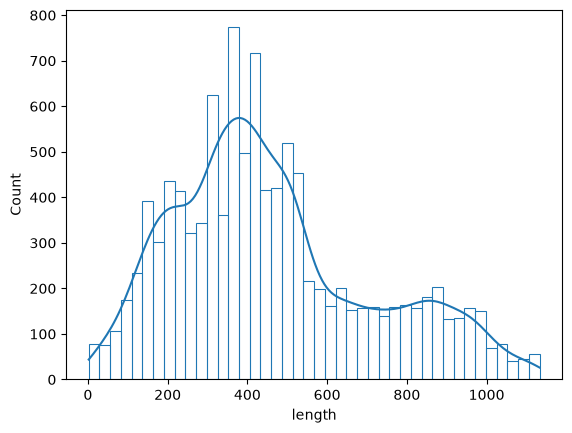

In [33]:
sns.histplot(data=df_data_filter, x="length", fill=False, kde=True)

<Axes: xlabel='length'>

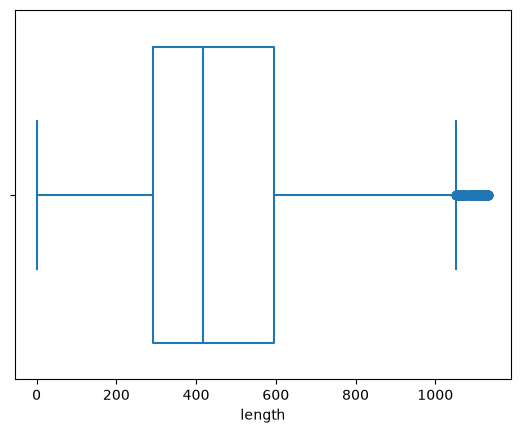

In [34]:
sns.boxplot(data=df_data_filter, x="length", fill=False)

In [35]:
df_data_filter2 = df_data_filter[df_data_filter["length"].between(70, 1024)]
df_data_filter2.shape

(10344, 8)

In [38]:
CANONICAL_RESIDUES = list("QAWSEDCRFVTGNHYMKILP")
print(len(CANONICAL_RESIDUES))
CANONICAL_RESIDUES


20


['Q',
 'A',
 'W',
 'S',
 'E',
 'D',
 'C',
 'R',
 'F',
 'V',
 'T',
 'G',
 'N',
 'H',
 'Y',
 'M',
 'K',
 'I',
 'L',
 'P']

In [ ]:
def  check_sequence(sequence:str)->bool:

    is_canon = True

    for residue in sequence:
        if residue not in CANONICAL_RESIDUES:
            is_canon=False
            break
        
    return is_canon

In [42]:
seq_demo = "MHDSGGVQMARALKHAALCLMLLPRFLLAAVMLWLLDFLCIRKKVLLKMGERQDGPDDPPVCVSDSNKMFTLESLRAVWYGQKLDFLKSAHLGRTAPNTEVMLVQERRQVRILDCMKGKRPLILNFGSCSUPPFMTRLAAFQRVVSQYADIADFLVVYIEEAHPSDGWVSSDAPYQIPKHRCLEDRLRAAQLMLAEVPGSNVVVDNMDNSSNAAYGAYFERLYIVRDERVVYQGGRGPEGYRISELRNWLEQYRNGLVNSQTAVLHV"

for residue in seq_demo:
    if residue not in CANONICAL_RESIDUES:
        print(residue)
        

U


In [39]:
df_data_filter2["is_canon"] = df_data_filter2["sequence"].apply(check_sequence)
df_data_filter2["is_canon"].value_counts()

is_canon
True     10289
False       55
Name: count, dtype: int64

In [43]:
df_data_filter_3 = df_data_filter2[df_data_filter2["is_canon"]]
df_data_filter_3.shape

(10289, 9)

In [44]:
df_data_filter_3.reset_index(inplace=True)
df_data_filter_3.head()

,index,id_seq,description,sequence,length,length_2,is_outlier,is_not_outlier,is_not_outlier_2,is_canon
0,0,sp|A0A061I403|FICD_CRIGR,sp|A0A061I403|FICD_CRIGR Protein adenylyltrans...,MPMASVIAVAEPKWISVWGRFLWLTLLSMALGSLLALLLPLGAVEE...,455,455,True,True,True,True
1,1,sp|A0A095C6S0|OXDA2_CRYD2,sp|A0A095C6S0|OXDA2_CRYD2 D-amino-acid oxidase...,MSFDAVVIGSGVIGLSIARELDNRGLKVAMVARDLAEDSLSVGFAS...,392,392,True,True,True,True
2,2,sp|A0A096MJN4|SEPT4_RAT,sp|A0A096MJN4|SEPT4_RAT Septin-4 OS=Rattus nor...,MIKHFLEDNSDDAELSKFVKDFPGSEPCHPTESKTRVARPQILEPR...,459,459,True,True,True,True
3,3,sp|A0A0B0QJR1|HEPT_APHF2,sp|A0A0B0QJR1|HEPT_APHF2 tRNA nuclease HepT OS...,MTNIEPVIIETRLELIGRYLDHLKKFENISLDDYLSSFEQQLITER...,147,147,True,True,True,True
4,4,sp|A0A0C1EH92|STMC_ASPUT,sp|A0A0C1EH92|STMC_ASPUT UDP-glycosyltransfera...,MTILSAERAPSRKILAVVTVGRYTCAAPILEICRILHTRGHTIEFA...,535,535,True,True,True,True


In [45]:
df_data_filter_3 = df_data_filter_3.drop(columns=["index", "length_2", "is_outlier", "is_not_outlier", "is_not_outlier_2", "is_canon"])
df_data_filter_3.head()

,id_seq,description,sequence,length
0,sp|A0A061I403|FICD_CRIGR,sp|A0A061I403|FICD_CRIGR Protein adenylyltrans...,MPMASVIAVAEPKWISVWGRFLWLTLLSMALGSLLALLLPLGAVEE...,455
1,sp|A0A095C6S0|OXDA2_CRYD2,sp|A0A095C6S0|OXDA2_CRYD2 D-amino-acid oxidase...,MSFDAVVIGSGVIGLSIARELDNRGLKVAMVARDLAEDSLSVGFAS...,392
2,sp|A0A096MJN4|SEPT4_RAT,sp|A0A096MJN4|SEPT4_RAT Septin-4 OS=Rattus nor...,MIKHFLEDNSDDAELSKFVKDFPGSEPCHPTESKTRVARPQILEPR...,459
3,sp|A0A0B0QJR1|HEPT_APHF2,sp|A0A0B0QJR1|HEPT_APHF2 tRNA nuclease HepT OS...,MTNIEPVIIETRLELIGRYLDHLKKFENISLDDYLSSFEQQLITER...,147
4,sp|A0A0C1EH92|STMC_ASPUT,sp|A0A0C1EH92|STMC_ASPUT UDP-glycosyltransfera...,MTILSAERAPSRKILAVVTVGRYTCAAPILEICRILHTRGHTIEFA...,535


In [47]:
df_data_filter_3 = df_data_filter_3.drop_duplicates(subset=["sequence"])
df_data_filter_3.shape

(9539, 4)

In [50]:
matrix_data = []

for sequence in df_data_filter_3["sequence"]:

    row = {
        "sequence" : sequence
    }

    for residue in CANONICAL_RESIDUES:
        row.update({residue: sequence.count(residue)/len(sequence)})
    
    matrix_data.append(row)

df_frequencies = pd.DataFrame(matrix_data)
df_frequencies.head()

,sequence,Q,A,W,S,E,D,C,R,F,...,T,G,N,H,Y,M,K,I,L,P
0,MPMASVIAVAEPKWISVWGRFLWLTLLSMALGSLLALLLPLGAVEE...,0.030769,0.074725,0.008791,0.059341,0.079121,0.037363,0.006593,0.059341,0.030769,...,0.065934,0.048352,0.026374,0.041758,0.032967,0.030769,0.054945,0.059341,0.125275,0.050549
1,MSFDAVVIGSGVIGLSIARELDNRGLKVAMVARDLAEDSLSVGFAS...,0.010204,0.091837,0.017857,0.081633,0.081633,0.048469,0.015306,0.053571,0.033163,...,0.022959,0.109694,0.028061,0.022959,0.038265,0.010204,0.066327,0.056122,0.084184,0.061224
2,MIKHFLEDNSDDAELSKFVKDFPGSEPCHPTESKTRVARPQILEPR...,0.045752,0.039216,0.008715,0.056645,0.087146,0.080610,0.021786,0.080610,0.045752,...,0.054466,0.047930,0.030501,0.028322,0.023965,0.021786,0.065359,0.047930,0.078431,0.067538
3,MTNIEPVIIETRLELIGRYLDHLKKFENISLDDYLSSFEQQLITER...,0.068027,0.047619,0.000000,0.068027,0.088435,0.061224,0.000000,0.040816,0.040816,...,0.047619,0.027211,0.054422,0.020408,0.054422,0.013605,0.047619,0.115646,0.142857,0.034014
4,MTILSAERAPSRKILAVVTVGRYTCAAPILEICRILHTRGHTIEFA...,0.033645,0.091589,0.018692,0.061682,0.054206,0.056075,0.013084,0.076636,0.039252,...,0.037383,0.059813,0.033645,0.035514,0.028037,0.035514,0.031776,0.061682,0.097196,0.063551
